# Cuaderno 03: Análisis Estadístico Exploratorio y Test de Schuster
**Autor:** Iván Andrés Mena Contreras
**Proyecto:** Lunar Tidal Triggering of Earthquakes

En este cuaderno realizaremos el análisis estadístico del catálogo filtrado ($M \geq 7.0$). El objetivo es identificar si existe una correlación estadística significativa entre las fases lunares y la ocurrencia de sismos, utilizando estadística circular y el Test de Schuster.

## Objetivos
1. **Cálculo de la Fase Lunar:** Estimar el ángulo de fase sinódica lunar (0°-360°) para cada sismo.
2. **Análisis Circular y Visualización:** Mapear la distribución temporal de eventos en un plano polar según la profundidad.
3. **Test de Schuster:** Evaluar estadísticamente si los sismos ocurren con una distribución uniforme (hipótesis nula) o si hay agrupación preferencial.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.time import Time
from astropy.coordinates import get_sun, get_body
from astropy import units as u

# Configuración de estilos visuales
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

# Crear directorios de salida si no existen
os.makedirs('../results/figures', exist_ok=True)

## 1. Carga y Preparación de Datos
Cargamos el catálogo previamente procesado.

In [2]:
# Cargar datos
data_path = '../data/processed/earthquakes_with_moon_final.csv'
df = pd.read_csv(data_path)

# Convertir time a datetime
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

print(f"Catálogo cargado: {len(df)} eventos")
df.head()

Catálogo cargado: 335 eventos


,id,time,latitude,longitude,depth,magnitude,place,type,julian_date,moon_ra,moon_dec,moon_distance_au
0,usp0006qyz,1995-01-06 22:37:34.320000+00:00,40.246,142.175,26.9,7.0,"63 km ESE of Hachinohe, Japan",earthquake,2.449724e+06,355.56230,2.06087,0.002612
1,usp0006sef,1995-02-05 22:51:05.140000+00:00,-37.759,178.752,21.1,7.1,"118 km NNE of Gisborne, New Zealand",earthquake,2.449754e+06,27.03611,12.09037,0.002670
2,usp0006vb3,1995-04-07 22:06:56.890000+00:00,-15.199,-173.529,21.2,7.4,"88 km NNE of Hihifo, Tonga",earthquake,2.449815e+06,104.91100,17.80052,0.002682
3,usp0006vz9,1995-04-21 00:34:46.090000+00:00,12.059,125.580,20.7,7.2,"10 km E of Dapdap, Philippines",earthquake,2.449829e+06,286.74051,-17.52783,0.002475
4,usp0006ww5,1995-05-05 03:53:45.050000+00:00,12.626,125.297,16.0,7.1,"14 km NE of Cabatuan, Philippines",earthquake,2.449843e+06,104.15054,17.88158,0.002699


## 2. Cálculo de la Fase Lunar
Para calcular la fase lunar de manera precisa, obtenemos las coordenadas ecuatoriales del Sol y la Luna utilizando Astropy. La fase puede aproximarse como la diferencia en Ascensión Recta (RA) entre la Luna y el Sol.

Una fase de $0^{\circ}$ corresponde a Luna Nueva, $90^{\circ}$ a Cuarto Creciente, $180^{\circ}$ a Luna Llena y $270^{\circ}$ a Cuarto Menguante.

In [3]:
def calcular_fase_lunar(fechas):
    """
    Calcula la fase lunar en grados (0 a 360) para una serie de fechas.
    """
    tiempos = Time(fechas)
    
    # Obtener posiciones aparentes del Sol y la Luna
    sol = get_sun(tiempos)
    luna = get_body('moon', tiempos)
    
    # La elongación (diferencia en Ascensión Recta)
    # Se ajusta para que el rango sea de 0 a 360 grados
    elongacion = luna.ra.degree - sol.ra.degree
    fase = np.mod(elongacion, 360.0)
    
    return fase

# Aplicar el cálculo al dataset
print("Calculando fases lunares...")
df['moon_phase_deg'] = calcular_fase_lunar(df['time'])
df['moon_phase_rad'] = np.radians(df['moon_phase_deg'])

print("Fases calculadas. Estadísticas:")
print(df['moon_phase_deg'].describe())

Calculando fases lunares...
Fases calculadas. Estadísticas:
count    335.000000
mean     177.111910
std      104.218998
min        0.324998
25%       75.625864
50%      185.266344
75%      264.816355
max      358.503228
Name: moon_phase_deg, dtype: float64


## 3. Segmentación por Profundidad
Se han observado diferencias en los mecanismos de ruptura de acuerdo a la profundidad. Separamos el catálogo en tres rangos (bins) corticales para análisis diferenciado:
- Superficiales: $0 - 20$ km
- Intermedios: $20 - 45$ km
- Profundos: $45 - 70$ km (y más)

In [4]:
def categorizar_profundidad(depth):
    if depth <= 20:
        return 'Superficial (0-20 km)'
    elif depth <= 45:
        return 'Intermedio (20-45 km)'
    else:
        return 'Profundo (>45 km)'

df['depth_category'] = df['depth'].apply(categorizar_profundidad)

print("Distribución por profundidad:")
print(df['depth_category'].value_counts())

Distribución por profundidad:
depth_category
Intermedio (20-45 km)    184
Superficial (0-20 km)    123
Profundo (>45 km)         28
Name: count, dtype: int64


## 4. Visualización Polar de las Fases
Visualizamos la distribución de sismos en un gráfico polar para identificar patrones de concentración. Cada punto representa un evento, posicionado según su fase lunar, tamaño según su magnitud y color según su profundidad.

<>:33: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:33: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\IVAN MENA\AppData\Local\Temp\ipykernel_19280\3852944983.py:33: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax.set_title('Distribución Polar de Terremotos (M$\geq$7.0) por Fase Lunar', fontsize=16, pad=20)


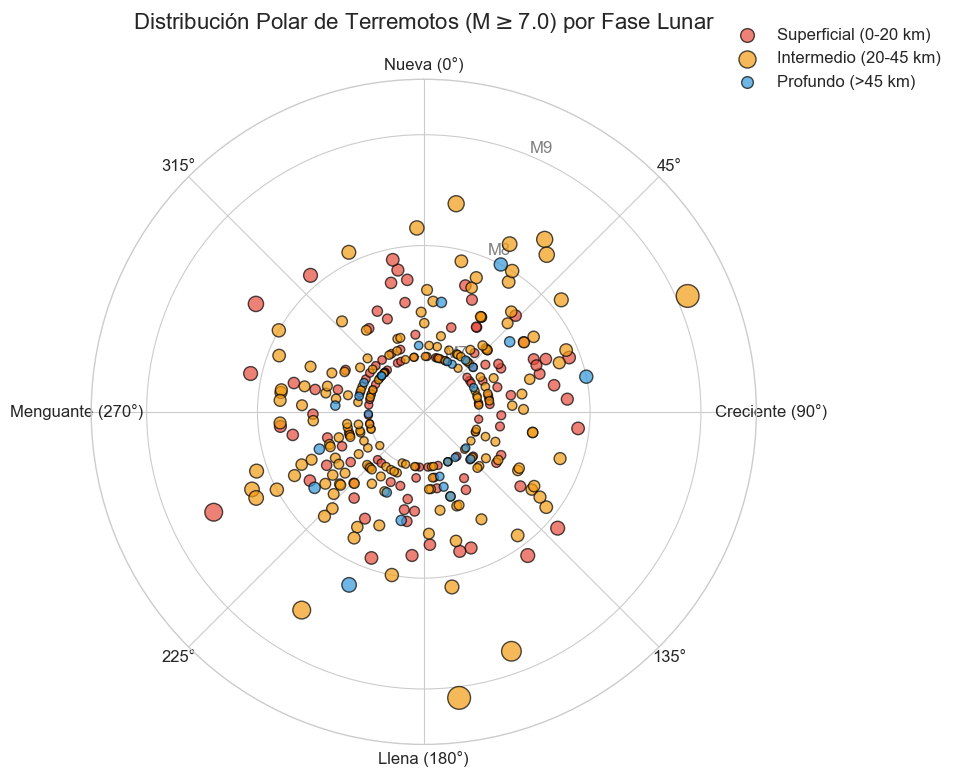

In [5]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

colores = {
    'Superficial (0-20 km)': '#e74c3c',  # Rojo
    'Intermedio (20-45 km)': '#f39c12',  # Naranja
    'Profundo (>45 km)': '#3498db'       # Azul
}

for categoria, color in colores.items():
    subset = df[df['depth_category'] == categoria]
    
    # El tamaño del marcador escalado exponencialmente según la magnitud
    tamanos = np.exp(subset['magnitude'] - 6.5) * 20
    
    # Ploteamos en el eje polar (theta=radianes, r=magnitud)
    # R se fijará alrededor de un radio base para no dispersar demasiado por magnitud,
    # pero podemos hacer que r refleje una constante o la magnitud misma.
    # Usaremos magnitud como radio para mayor claridad visual.
    ax.scatter(subset['moon_phase_rad'], subset['magnitude'], 
               c=color, s=tamanos, alpha=0.7, edgecolors='k', label=categoria)

# Configuración de los ejes polares
ax.set_theta_zero_location('N') # 0° arriba (Luna Nueva)
ax.set_theta_direction(-1) # Sentido horario
ax.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
ax.set_xticklabels(['Nueva (0°)', '45°', 'Creciente (90°)', '135°', 
                    'Llena (180°)', '225°', 'Menguante (270°)', '315°'])

# Ajuste del radio
ax.set_ylim(6.5, 9.5)
ax.set_yticks([7.0, 8.0, 9.0])
ax.set_yticklabels(['M7', 'M8', 'M9'], color='grey')
ax.set_title('Distribución Polar de Terremotos (M$\geq$7.0) por Fase Lunar', fontsize=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../results/figures/03_polar_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Test de Schuster
El Test de Schuster es una prueba estadística rigurosa para evaluar la periodicidad en series temporales direccionales.
Calculamos el vector suma $R$:
$R = \sqrt{(\sum \cos \phi_i)^2 + (\sum \sin \phi_i)^2}$

La probabilidad $p$-value de que esta distribución provenga de una distribución aleatoria uniforme se aproxima como:
$p = e^{-R^2/N}$

Si $p < 0.05$, rechazamos la hipótesis nula y concluimos que existe una periodicidad o agrupamiento significativo.

In [6]:
def schuster_test(fases_rad):
    """
    Realiza el Test de Schuster para detectar agrupamientos circulares.
    Retorna el vector R y el valor p.
    """
    N = len(fases_rad)
    if N == 0:
        return np.nan, np.nan
        
    sum_cos = np.sum(np.cos(fases_rad))
    sum_sin = np.sum(np.sin(fases_rad))
    
    R = np.sqrt(sum_cos**2 + sum_sin**2)
    p_value = np.exp(-(R**2) / N)
    
    return R, p_value

# 1. Test para todo el catálogo
R_total, p_total = schuster_test(df['moon_phase_rad'])

# 2. Test para sismos superficiales (<20km)
sismos_superficiales = df[df['depth'] < 20]
R_superf, p_superf = schuster_test(sismos_superficiales['moon_phase_rad'])

print("=== RESULTADOS DEL TEST DE SCHUSTER ===")
print(f"Catálogo Completo (N={len(df)}):")
print(f"  Vector R: {R_total:.4f}")
print(f"  p-value:  {p_total:.4g} " + ("(Significativo)" if p_total < 0.05 else "(No significativo)"))
print()
print(f"Sismos Superficiales <20km (N={len(sismos_superficiales)}):")
print(f"  Vector R: {R_superf:.4f}")
print(f"  p-value:  {p_superf:.4g} " + ("(Significativo)" if p_superf < 0.05 else "(No significativo)"))

=== RESULTADOS DEL TEST DE SCHUSTER ===
Catálogo Completo (N=335):
  Vector R: 17.2473
  p-value:  0.4115 (No significativo)

Sismos Superficiales <20km (N=116):
  Vector R: 9.4913
  p-value:  0.46 (No significativo)


## 6. Histograma de Frecuencias
Finalmente, observaremos la distribución en un histograma con bins de $15^{\circ}$ para verificar visualmente cualquier desviación respecto a una distribución uniforme (hipótesis nula).

<>:9: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:9: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\IVAN MENA\AppData\Local\Temp\ipykernel_19280\2277273211.py:9: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax1.set_title('Distribución de Frecuencias: Catálogo Completo (M$\geq$7.0)', fontsize=14)


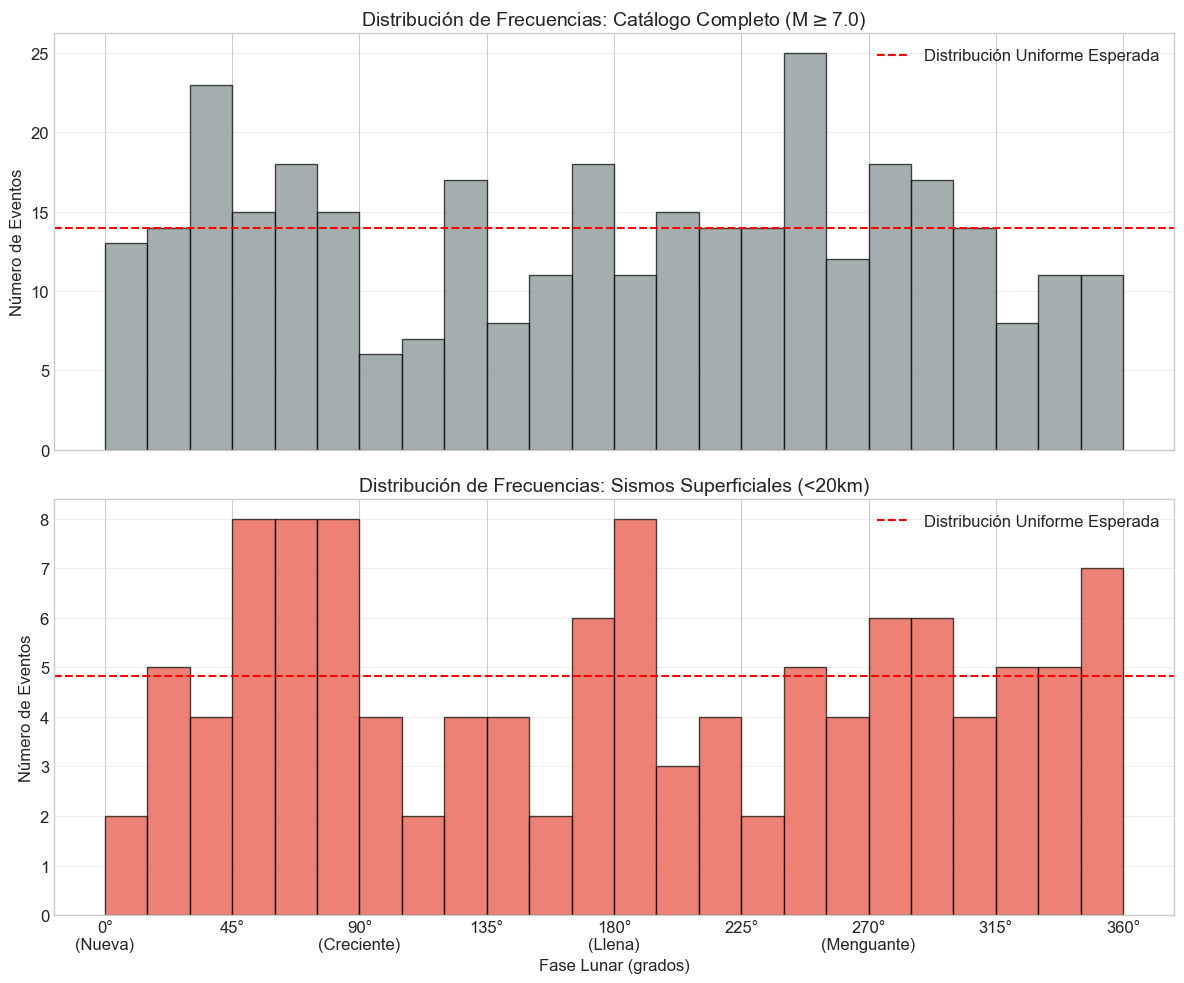

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Bins de 15 grados
bins = np.arange(0, 361, 15)

# Plot para catálogo completo
counts_total, _, _ = ax1.hist(df['moon_phase_deg'], bins=bins, color='#7f8c8d', alpha=0.7, edgecolor='black')
ax1.axhline(len(df) / (360/15), color='red', linestyle='--', label='Distribución Uniforme Esperada')
ax1.set_title('Distribución de Frecuencias: Catálogo Completo (M$\geq$7.0)', fontsize=14)
ax1.set_ylabel('Número de Eventos')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot para superficiales
counts_sup, _, _ = ax2.hist(sismos_superficiales['moon_phase_deg'], bins=bins, color='#e74c3c', alpha=0.7, edgecolor='black')
ax2.axhline(len(sismos_superficiales) / (360/15), color='red', linestyle='--', label='Distribución Uniforme Esperada')
ax2.set_title('Distribución de Frecuencias: Sismos Superficiales (<20km)', fontsize=14)
ax2.set_xlabel('Fase Lunar (grados)')
ax2.set_ylabel('Número de Eventos')
ax2.set_xticks(np.arange(0, 361, 45))
ax2.set_xticklabels(['0°\n(Nueva)', '45°', '90°\n(Creciente)', '135°', '180°\n(Llena)', '225°', '270°\n(Menguante)', '315°', '360°'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/03_schuster_test.png', dpi=300, bbox_inches='tight')
plt.show()